**<h1>1. Data Loading</h1>**

<p>This section explains how to prepare and load the dataset required for the project.</p>

<ul>
  <li>Create a folder named <strong>datatests</strong> in the project directory. This folder will be used to store the dataset.</li>
  <li>Download the dataset from the provided source.</li>
  <li>Place the downloaded dataset files into the <strong>datatests</strong> folder.</li>
</ul>

Before running the model, verify whether a GPU is available on your system to accelerate the training process.

In [1]:
!nvidia-smi

Sat Mar 14 02:04:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             51W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import os


PATH = '/content/dataset'
DATA_PATH = '/content/dataset/Images'

if not os.path.exists(PATH):
  os.mkdir(PATH)


Check the GPU is available or not because we will use GPU for training

Install the `gdown` library to easily download files from external sources such as Google Drive.

In [3]:
!pip install gdown

Place the dataset into the project directory so it can be accessed during the training and evaluation process.

In [4]:
import gdown, zipfile, os

if not os.path.exists(f'{PATH}/list.txt'):
    os.makedirs(PATH, exist_ok=True)
    url = 'https://drive.google.com/uc?id=16K1Luqqa496n5Oe1XIDWd3llgMMp93vH'
    gdown.download(url, f"{PATH}/list.txt", quiet=False)

if not os.path.exists(DATA_PATH):
    os.makedirs(DATA_PATH, exist_ok=True)
    url = "https://drive.google.com/uc?id=1MabG8IDYbKVyPDKwl0GnPvQ4csywDYy0"
    gdown.download(url, f"{PATH}/Images.zip", quiet=False)

    with zipfile.ZipFile(f"{PATH}/Images.zip", 'r') as z:
        z.extractall(PATH)

    print("Done!")

Downloading...
From: https://drive.google.com/uc?id=16K1Luqqa496n5Oe1XIDWd3llgMMp93vH
To: /content/dataset/list.txt
100%|██████████| 26.7M/26.7M [00:00<00:00, 60.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1MabG8IDYbKVyPDKwl0GnPvQ4csywDYy0
From (redirected): https://drive.google.com/uc?id=1MabG8IDYbKVyPDKwl0GnPvQ4csywDYy0&confirm=t&uuid=9d837290-5957-42bf-8f93-f1b60caf2c48
To: /content/dataset/Images.zip
100%|██████████| 35.8M/35.8M [00:00<00:00, 56.9MB/s]


Done!


**<h1>2. Data Exploratory to cleaning data</h1>**



<ul>
  <li>Load the dataset into a dataframe for further analysis.</li>
  <li>Convert negative labels in the dataframe from <strong>-1</strong> to <strong>0</strong>.</li>
  <li>Check for any null or missing values in the dataframe.</li>
  <li>Clean the dataframe to ensure that only images that exist in the dataset folder are included.</li>
  <li>Verify that all image files are valid and not corrupted.</li>
  <li>Check the image sizes in the dataset to ensure they are consistent.</li>
</ul>

In [5]:
import pandas as pd
import re

with open(f"{PATH}/list.txt", "r") as f:
    lines = f.readlines()

attr_names = lines[1].strip().split()

data = []
for line in lines[2:]:
    parts = line.strip().split()
    if not parts:
        continue
    filename = parts[0]
    attrs = [int(x) for x in parts[1:] if x in ('1', '-1')]
    data.append([filename] + attrs)

columns = ["filename"] + attr_names

n_attrs = len(attr_names)
data = [row for row in data if len(row) == n_attrs + 1]

df = pd.DataFrame(data, columns=columns)
print(df.head(10))

     filename  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   
5  000006.jpg                -1                1           1               -1   
6  000007.jpg                 1               -1           1                1   
7  000008.jpg                 1                1          -1                1   
8  000009.jpg                -1                1           1               -1   
9  000010.jpg                -1               -1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -

Replace label values of -1 with 0 to ensure that the labels are valid and compatible with the model during training.


In [6]:
df = df[['filename', 'Male']]
df.loc[df['Male'] == -1, 'Male'] = 0
df

,filename,Male
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,1
3,000004.jpg,0
4,000005.jpg,0
...,...,...
202594,202595.jpg,0
202595,202596.jpg,1
202596,202597.jpg,1
202597,202598.jpg,0


Check null values make sure there is no value for the data if the null values is exists we need to clean it up first

In [7]:
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nUnique values in 'Male': {df['Male'].unique()}")
print(f"\nValue counts:\n{df['Male'].value_counts()}")

ext = df['filename'].str.split('.').str[-1].str.lower()

print(f"\nExtension Value counts:\n{ext.value_counts()}")

Shape: (202599, 2)

Dtypes:
filename    object
Male         int64
dtype: object

Null values:
filename    0
Male        0
dtype: int64

Unique values in 'Male': [0 1]

Value counts:
Male
0    118165
1     84434
Name: count, dtype: int64

Extension Value counts:
filename
jpg    202599
Name: count, dtype: int64


In [8]:
if(len(df[df['filename'].str.contains(r"\(\d+\)", regex=True)]) == 0):
  print("not duplicate image founded")

not duplicate image founded


Display the total number of images in the dataset to verify that all data has been loaded correctly.

In [9]:
import os

image_list = [f for f in os.listdir(DATA_PATH) if f.lower().endswith(('.jpg'))]

print(f"Number of images : {len(image_list)}")

Number of images : 5017


Make sure the dataframe only include the files that is exists in image folder

In [10]:
df = df[df['filename'].isin(image_list)]
print(f"Shape after filter: {df.shape}")

df.head(10)

Shape after filter: (5000, 2)


,filename,Male
50,000051.jpg,1
51,000052.jpg,1
64,000065.jpg,1
165,000166.jpg,1
197,000198.jpg,0
200,000201.jpg,0
239,000240.jpg,0
281,000282.jpg,1
351,000352.jpg,1
408,000409.jpg,1


Verify that all image files in the dataset folder are valid and not corrupted before starting the training process.

In [11]:
from PIL import Image
def is_valid(filename):
    path = os.path.join(DATA_PATH, filename)
    try:
        with Image.open(path) as img :
          img.verify()
          return True
    except:
        return False

print(f"Corrupt files: {(~ df['filename'].apply(is_valid)).sum()}")

Corrupt files: 0


Check the dimensions of all images to ensure consistency in image size across the dataset.

In [12]:
import os
from PIL import Image
from collections import Counter

def check_image_size(df, DATA_PATH):
  sizes = []

  for filename in df['filename']:
    path = os.path.join(DATA_PATH, filename)

    with Image.open(path) as img:
      width, height = img.size
      sizes.append((width, height))

  size_count = Counter(sizes)

  print("Different Image size :", len(size_count))
  print("\nDetail size:")

  for size, count in size_count.items():
    print(f"Size {size} : {count} gambar")

  return size_count

In [13]:
check_image_size(df, DATA_PATH)

Different Image size : 1

Detail size:
Size (178, 218) : 5000 gambar


Counter({(178, 218): 5000})

Plot the first 10 images from the dataset to visually inspect them and ensure that the images are clean and correctly loaded.

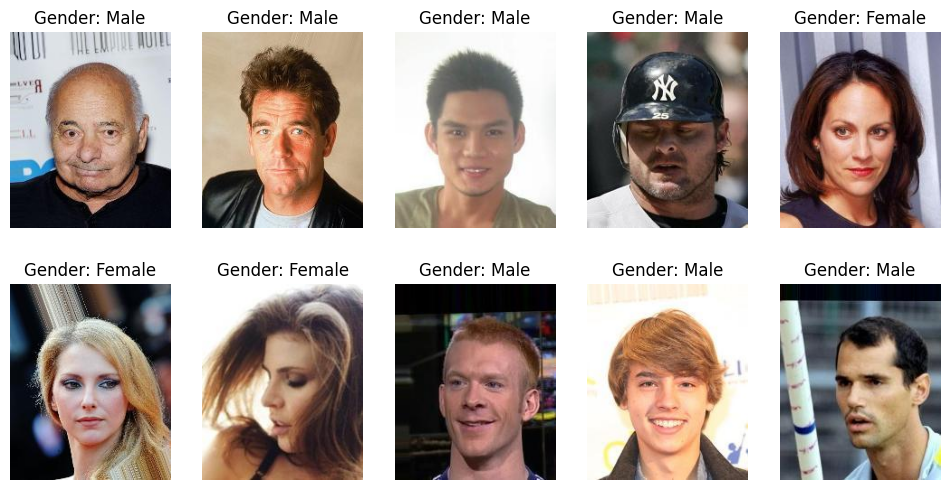

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i , ax in enumerate(axes.flatten()):
    row = df.iloc[i]
    dir = f"{DATA_PATH}/{row['filename']}"
    image = Image.open(dir)
    ax.imshow(image)
    ax.set_title(f"Gender: {'Male' if row['Male'] == 1 else 'Female'}")
    ax.axis('off')


**<h1>3. Data Preprocessing before training</h1>**



<ul>
  <li>Split the dataset using <strong>stratified sampling</strong> for the training set and <strong>random sampling</strong> for the validation and test sets.</li>
  <li>Construct a PyTorch <strong>Dataset</strong> from the dataframe.</li>
  <li>Set the computation device to <strong>CUDA</strong> if a GPU is available.</li>
  <li>Set a <strong>manual seed</strong> to ensure reproducibility.</li>
  <li>Define evaluation metrics for model performance.</li>
</ul>

Split the dataset using the stratify sampling in training set and use random sampling in validate and test set , stratify to training set to make sure the training set is balance.

In [15]:
from sklearn.model_selection import train_test_split

male_df = df[df['Male'] == 1]
female_df = df[df['Male'] == 0]

male_train = male_df.sample(1750, random_state=42)
female_train = female_df.sample(1750, random_state=42)

df_train = pd.concat([male_train, female_train])

df_rest = df.drop(df_train.index)

df_val , df_test = train_test_split(df_rest, test_size=500, random_state=42)

print(f"Train samples: {len(df_train)}")
print(f"Validation samples: {len(df_val)}")
print(f"Test samples: {len(df_test)}")

Train samples: 3500
Validation samples: 1000
Test samples: 500


Verify the number of samples in each class to ensure that the training dataset is balanced.

In [16]:
def check_data_count(df):
    num_male = (df['Male'] == 1).sum()
    print(f"Male count: {num_male}")
    print(f"Percent count Male: {num_male / len(df) * 100:.2f} %")

    num_female = (df['Male'] == 0).sum()
    print(f"Female count: {num_female}")
    print(f"Percent count Female: {num_female / len(df) * 100:.2f} %")

In [17]:
for df in (df_train , df_val, df_test):
  check_data_count(df)

  print('\n')

Male count: 1750
Percent count Male: 50.00 %
Female count: 1750
Percent count Female: 50.00 %


Male count: 203
Percent count Male: 20.30 %
Female count: 797
Percent count Female: 79.70 %


Male count: 94
Percent count Male: 18.80 %
Female count: 406
Percent count Female: 81.20 %




**<h1>4. Data Modelling</h1>**

<ul>
  <li>Define the evaluation metrics to measure model performance.</li>
  <li>Define and initialize the model architecture.</li>
  <li>Perform hyperparameter tuning to optimize model performance.</li>
  <li>Train the model using the prepared training dataset.</li>
</ul>

Install torchmetrics to use the metrics for this classification problem

In [18]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.6 MB/s eta 0:00:00


Import the required libraries that will be used to train the model and set the computation device to GPU if available.  
Select the model architectures to be used for solving this classification problem. In this project, the following models are used:

- ResNet18
- ResNet50
- ResNet152

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam,AdamW
from torchmetrics.classification import BinaryAccuracy , BinaryAUROC, BinaryF1Score
from torch.utils.data import Dataset , DataLoader
from torchvision.models import resnet50 , ResNet50_Weights , resnet18 , ResNet18_Weights, resnet152, ResNet152_Weights

transformResnet50 = ResNet50_Weights.DEFAULT.transforms()
transformResnet18 = ResNet18_Weights.DEFAULT.transforms()
transformResnet152 = ResNet152_Weights.DEFAULT.transforms()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Check the computation device to ensure that PyTorch is running on CUDA (GPU).

In [20]:
device.type

'cuda'

In [21]:
transformResnet50 , transformResnet18, transformResnet152

(ImageClassification(
     crop_size=[224]
     resize_size=[232]
     mean=[0.485, 0.456, 0.406]
     std=[0.229, 0.224, 0.225]
     interpolation=InterpolationMode.BILINEAR
 ),
 ImageClassification(
     crop_size=[224]
     resize_size=[256]
     mean=[0.485, 0.456, 0.406]
     std=[0.229, 0.224, 0.225]
     interpolation=InterpolationMode.BILINEAR
 ),
 ImageClassification(
     crop_size=[224]
     resize_size=[232]
     mean=[0.485, 0.456, 0.406]
     std=[0.229, 0.224, 0.225]
     interpolation=InterpolationMode.BILINEAR
 ))

Convert the dataset into a PyTorch Dataset object to enable efficient data loading and preprocessing during model training.

In [22]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset

class ImageDataset(Dataset):

    def __init__(self, df, img_dir, transform=None, device='cpu'):
        self.data = df
        self.img_dir = img_dir
        self.transform = transform
        self.device = device

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.data.iloc[idx, 0])
        image = Image.open(img_path).convert("RGB")
        label = self.data.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)

        image = image.to(self.device)
        label = torch.tensor(label, dtype=torch.long, device=self.device)

        return image, label

In [23]:
dataset_train = ImageDataset(df_train , DATA_PATH, transform=None, device=device)
dataset_val = ImageDataset(df_val, DATA_PATH, transform=None, device=device)
dataset_test = ImageDataset(df_test, DATA_PATH, transform=None, device=device)


Load the dataset into the dataloader

In [24]:
batch_size = 32

train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(dataset_test, batch_size=batch_size, shuffle=False,)

Set the random seed

In [25]:
import numpy as np

def set_seed(seed=42):
    torch.manual_seed(seed)
    if device.type == 'cuda':
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(42)


Define the matrices that will be use for our classification problem :

* **Accuracy** : the number of correct predictions divided by the total number of predictions. It measures the overall performance of the model in correctly classifying both positive and negative samples.

$$
Acc = \frac{TP + TN}{TP + TN + FP + FN}
$$

* **F1 Score** : the harmonic mean of precision and recall. It provides a balance between precision and recall, especially useful when dealing with imbalanced datasets.

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

* **AUROC (Area Under the Receiver Operating Characteristic Curve)** : a metric that measures the ability of a model to distinguish between classes. A higher AUROC value indicates that the model is better at separating positive and negative classes.

$$
AUC = \int_{0}^{1} \frac{TP}{TP + FN}\, d\left(\frac{FP}{FP + TN}\right)
$$

In [26]:
accuracy = BinaryAccuracy().to(device)
f1_score = BinaryF1Score().to(device)
binary_auc = BinaryAUROC().to(device)

criterion = nn.BCEWithLogitsLoss().to(device)

Define the training functions :

*   Define the evaluate step
*   Define the test step
*   Define the train step



Define evaluate step that will be use for validation

In [27]:
def evaluate_step(model, val_loader,criterion ,accuracy , f1_score , binary_auc):

    accuracy.reset()
    f1_score.reset()
    binary_auc.reset()
    model.eval()

    total_loss = 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(val_loader):

            X, y = X.to(device), y.float().to(device)
            y_pred = model(X).squeeze(1)
            loss = criterion(y_pred, y)
            total_loss += loss.item()

            sigmoid = torch.sigmoid(y_pred)
            accuracy.update(sigmoid, y.int())
            f1_score.update(sigmoid, y.int())
            binary_auc.update(sigmoid, y.int())

    val_loss = total_loss / len(val_loader)
    val_acc  = accuracy.compute().item()
    va_f1 = f1_score.compute().item()
    val_auc = binary_auc.compute().item()

    return val_acc, val_loss , va_f1 , val_auc


Define test step that will be use for test

In [28]:
from sklearn.metrics import confusion_matrix

def test_step(model, test_loader, criterion, accuracy, f1_score, binary_auc):
    model.eval()

    accuracy.reset()
    f1_score.reset()
    binary_auc.reset()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for batch, (X, y) in enumerate(test_loader):
            X, y = X.to(device), y.float().to(device)

            y_pred = model(X).squeeze(1)
            loss = criterion(y_pred, y)
            total_loss += loss.item()

            sigmoid = torch.sigmoid(y_pred)

            accuracy.update(sigmoid, y.int())
            f1_score.update(sigmoid, y.int())
            binary_auc.update(sigmoid, y.int())

            preds_label = (sigmoid >= 0.5).int()
            all_preds.append(preds_label.cpu())
            all_labels.append(y.int().cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())

    val_loss = total_loss / len(test_loader)
    val_acc = accuracy.compute().item()
    val_f1 = f1_score.compute().item()
    val_auc = binary_auc.compute().item()

    return val_acc, val_loss, val_f1, val_auc, cm

Define train step that will be use for training

In [29]:
def train_step(model, optimizer, train_loader, criterion, accuracy, f1_score , binary_auc):

    model.train()
    accuracy.reset()
    f1_score.reset()
    binary_auc.reset()
    total_loss = 0.0

    for batch, (X, y) in enumerate(train_loader):
        X, y = X.to(device), y.float().to(device)

        optimizer.zero_grad()

        y_pred = model(X).squeeze(1)
        loss = criterion(y_pred, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()
        sigmoid = torch.sigmoid(y_pred)
        accuracy.update(sigmoid, y.int())
        f1_score.update(sigmoid, y.int())
        binary_auc.update(sigmoid, y.int())

    avg_loss = total_loss / len(train_loader)
    accuracy_score = accuracy.compute().item()
    f1_score_value = f1_score.compute().item()
    auc_score = binary_auc.compute().item()

    return avg_loss, accuracy_score , f1_score_value , auc_score

Define models that will be used an freeze the FC layers because we won't use the FC layer in our training

In [30]:
def get_model(model_class, weights):
    model = model_class(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(device)

Define the model we will use to training the model currentyly :

* Resnet18
* Resnet50
* Resnet152

In [31]:
models = {
    "resnet18":  (lambda: get_model(resnet18,  ResNet18_Weights.DEFAULT),  ResNet18_Weights.DEFAULT),
    "resnet50":  (lambda: get_model(resnet50,  ResNet50_Weights.DEFAULT),  ResNet50_Weights.DEFAULT),
    "resnet152": (lambda: get_model(resnet152, ResNet152_Weights.DEFAULT), ResNet152_Weights.DEFAULT),
}

Install optuna the required hyperparameter framework to do the hyperparameter tuning

In [32]:
!pip install optuna



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 17.3 MB/s eta 0:00:00


Initiate the train function to training the dataset

In [33]:
def train(model, train_loader, val_loader, optimizer, criterion, accuracy,f1_score, auc , epochs,model_name):
    best_acc = 0
    best_loss = float('inf')
    patience = 5
    no_improve = 0

    train_losses, train_accuracys, train_f1s, train_aucs = [], [], [], []
    val_losses, val_accuracys, val_f1s, val_aucs = [], [], [], []

    for epoch in range(epochs):
        train_loss, train_acc, train_f1, train_auc = train_step(
            model, optimizer, train_loader, criterion,
            accuracy, f1_score, binary_auc
        )

        val_acc, val_loss, val_f1, val_auc = evaluate_step(
            model, val_loader, criterion,
            accuracy, f1_score, binary_auc
        )

        train_losses.append(train_loss)
        train_accuracys.append(train_acc)
        train_f1s.append(train_f1)
        train_aucs.append(train_auc)

        val_losses.append(val_loss)
        val_accuracys.append(val_acc)
        val_f1s.append(val_f1)
        val_aucs.append(val_auc)

        accuracy_increased = val_acc > best_acc
        loss_decreassed = val_loss < best_loss
        accuracy_same = val_acc == best_acc

        if accuracy_increased :
            best_acc = val_acc
            torch.save(model.state_dict(), model_name)
            print(f"Model saved! with accuracy {val_acc*100:.2f}%  f1_score {val_f1:.4f}, val_auc {val_auc:.4f} and losses {val_loss:.4f}")
        elif accuracy_same :
            if loss_decreassed :
              torch.save(model.state_dict(), model_name)
              print(f"Model saved! with accuracy {val_acc*100:.2f}%  f1_score {val_f1:.4f}, val_auc {val_auc:.4f} and losses {val_loss:.4f}")

        if loss_decreassed :
            best_loss = val_loss

        if accuracy_increased or loss_decreassed:
            no_improve = 0
        else:
            no_improve += 1


        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch: {epoch+1}")
            print(
                f"Train | "
                f"Loss={train_loss:.4f} | "
                f"Acc={train_acc*100:.2f}% | "
                f"F1={train_f1:.4f} | "
                f"AUC={train_auc:.4f}"
            )

            print(
                f"Val   | "
                f"Loss={val_loss:.4f} | "
                f"Acc={val_acc*100:.2f}% | "
                f"F1={val_f1:.4f} | "
                f"AUC={val_auc:.4f}"
            )


    return {
        "best_acc": best_acc,
        "train_losses": train_losses,
        "train_accuracys": train_accuracys,
        "train_f1s": train_f1s,
        "train_aucs": train_aucs,
        "val_losses": val_losses,
        "val_accuracys": val_accuracys,
        "val_f1s": val_f1s,
        "val_aucs": val_aucs,
        "score" : best_acc - 0.1 * best_loss
    }

Hyperparameter Tuning

Hyperparameter tuning is performed to determine the optimal configuration of training parameters that maximize the performance of the classification model. In this experiment, hyperparameter optimization is conducted using the Optuna framework, which automatically searches for the best hyperparameter combination during the training process.



* **Learning Rate**

  The learning rate controls the step size used when updating the model parameters during the optimization process. It determines how quickly the model learns from the training data. A smaller learning rate leads to slower but more stable convergence, while a larger learning rate may accelerate learning but can cause unstable training.

  The learning rate is denoted as:

  $$
  \eta
  $$

  The search range for the learning rate is defined as:

  $$
  10^{-6} \leq \eta \leq 10^{-2}
  $$

 * **Optimizer**

    The optimizer is responsible for updating model parameters based on the gradients computed during backpropagation. In this study, two adaptive optimization algorithms are considered.

    $$
    Optimizer \in \{Adam, AdamW\}
    $$

    Adam uses adaptive learning rates for each parameter, while AdamW introduces weight decay regularization that improves generalization performance.

    The Adam optimizer (Adaptive Moment Estimation) combines the advantages of momentum and adaptive learning rates to achieve faster convergence during training. Adam maintains two moving averages of the gradients: the first moment (mean of gradients) and the second moment (variance of gradients).

    The gradient at iteration $t$ is computed as:

    $$
    g_t = \nabla_{\theta} L(\theta_t)
    $$

    where $L(\theta)$ represents the loss function and $\theta$ denotes the model parameters.

    The first moment estimate (mean of gradients) is calculated as:

    $$
    m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
    $$

    The second moment estimate (uncentered variance of gradients) is calculated as:

    $$
    v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2
    $$

    To correct the bias introduced during initialization, bias-corrected estimates are computed as:

    $$
    \hat{m}_t = \frac{m_t}{1 - \beta_1^t}
    $$

    $$
    \hat{v}_t = \frac{v_t}{1 - \beta_2^t}
    $$

    Finally, the model parameters are updated using the following rule:

    $$
    \theta_{t+1} =
    \theta_t -
    \eta
    \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
    $$

    where $\eta$ represents the learning rate and $\epsilon$ is a small constant added for numerical stability.



* **Beta1**

    The parameter $\beta_1$ represents the exponential decay rate for the first moment estimate in the optimizer. It controls how much past gradient information contributes to the current update.

    The search range is defined as:

    $$
    0.85 \leq \beta_1 \leq 0.95
    $$

    Higher values make the optimizer rely more on previous gradients, resulting in smoother but slower updates.



* **Beta2**

    The parameter $\beta_2$ represents the exponential decay rate for the second moment estimate, which tracks the variance of the gradients.

    The search range is defined as:

    $$
    0.99 \leq \beta_2 \leq 0.9999
    $$

    Higher values produce more stable gradient updates by smoothing the squared gradient estimates.


* **Weight Decay**

    Weight decay is a regularization parameter used to prevent overfitting by penalizing large model weights. This parameter is applied when using the AdamW optimizer.

    The weight decay coefficient is denoted as:

    $$
    \lambda
    $$

    The search range is defined as:

    $$
    10^{-6} \leq \lambda \leq 10^{-2}
    $$

    Weight decay helps the model generalize better by discouraging overly large parameter values during training.

In [34]:
import torch
from torch.optim import Adam, AdamW
import optuna

def objective(
    trial,
    model_name_str,
    criterion,
    train_loader,
    val_loader,
    accuracy,
    f1_score,
    binary_auc
):
    learning_rate = trial.suggest_float("learning_rate", 1e-6, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])
    beta1 = trial.suggest_float("beta1", 0.85, 0.95)
    beta2 = trial.suggest_float("beta2", 0.99, 0.9999)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    model_factory, weights = models[model_name_str]
    model = model_factory().to(device)

    if optimizer_name == "Adam":
        optimizer = Adam(model.parameters(), lr=learning_rate, betas=(beta1, beta2))
    else:
        optimizer = AdamW(model.parameters(), lr=learning_rate, betas=(beta1, beta2), weight_decay=weight_decay)

    train_loader.dataset.transform = weights.transforms()
    val_loader.dataset.transform = weights.transforms()

    train_results = train(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        accuracy,
        f1_score,
        binary_auc,
        epochs=50,
        model_name=f"{model_name_str}.pth"
    )

    best_score = train_results["score"]
    best_f1 = max(train_results["val_f1s"])
    best_auc = max(train_results["val_aucs"])
    val_loss_last = train_results["val_losses"][-1]

    for step, val_acc_epoch in enumerate(train_results["val_accuracys"]):
        trial.report(val_acc_epoch, step)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()



    return best_score


Several utility functions are defined to analyze and visualize the performance of the trained models.

- **Learning Comparison Plot**: Used to visualize and compare the training and validation metrics of each model during the training process.
- **Best Model Performance**: Used to display the best evaluation results obtained by each model based on the selected performance metrics.
- **Training Time Plot**: Used to visualize and compare the training time required by each model.

In [35]:
def learning_comparasion_plot(history):

  metrics = ['loss', 'acc', 'f1', 'auc']
  metric_names = ['Loss', 'Accuracy', 'F1 Score', 'AUC']

  for i, metric in enumerate(metrics):
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    for model_name in history.keys():
      plt.plot(history[model_name][f'train_{metric}'], label=f'{model_name}')
    plt.xlabel('Epoch')
    plt.ylabel(metric_names[i])
    plt.title(f'Train {metric_names[i]} vs Epoch')
    plt.legend()

    plt.subplot(1,2,2)
    for model_name in history.keys():
      plt.plot(history[model_name][f'val_{metric}'], label=f'{model_name}')
    plt.xlabel('Epoch')
    plt.ylabel(metric_names[i])
    plt.title(f'Validation {metric_names[i]} vs Epoch')
    plt.legend()
    plt.show()

In [36]:
import matplotlib.pyplot as plt

def plot_best_matrics(history):
  metrics = ['acc', 'f1', 'auc']
  metric_display_names = [ 'Accuracy', 'F1 Score', 'AUC']

  plt.figure(figsize=(18,6))
  model_names = list(history.keys())

  for i, metric in enumerate(metrics):
    best_metric_values = []
    for model_name in model_names:
      best_metric_values.append(max(history[model_name][f'val_{metric}']))

    plt.subplot(1,3,i+1)
    plt.bar(model_names, best_metric_values, color =['skyblue', 'lightgreen', 'salmon'])

    plt.ylabel(f"Best {metric_display_names[i]}")
    plt.title(f"Best {metric_display_names[i]} Comparison")

    for j, v in enumerate(best_metric_values):
      plt.text(j, v + 0.01, f"{v:.2f}", ha='center')

  plt.tight_layout()
  plt.show()


In [37]:
def plot_training_time(training_times):
  plt.figure(figsize=(12,6))
  plt.bar(training_times.keys(), training_times.values(),color =['skyblue', 'lightgreen', 'salmon'])
  plt.xlabel('Model')
  plt.ylabel('Training Time (seconds)')
  plt.title('Training Time Comparison')
  plt.legend()
  plt.show()

Finally, the hyperparameter tuning process can begin. In this stage, different combinations of hyperparameters are explored to find the configuration that produces the best model performance on the validation dataset.

In [38]:
from optuna.visualization import plot_param_importances,plot_optimization_history
from plotly.subplots import make_subplots

In [39]:
best_results = {}
plots = {}

for model_name in models.keys():
    study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
        sampler=optuna.samplers.TPESampler(seed=42),
        study_name=f"tuning_{model_name}"
    )

    study.optimize(
        lambda trial, m=model_name: objective(
            trial, m, criterion, train_loader, val_loader, accuracy, f1_score, binary_auc
        ),
        n_trials=5,
        show_progress_bar=True
    )


    best_results[model_name] = {
        "best_trial": study.best_trial,
        "best_value": study.best_value,
        "best_params": study.best_params
    }

    plots[model_name] = {
      "history": plot_optimization_history(study),
      "importance": plot_param_importances(study)
    }

    print(f"\n{model_name} → Best score: {study.best_value:.2f}%")
    print(f"Best score: {study.best_params}")


[I 2026-03-14 02:04:50,965] A new study created in memory with name: tuning_resnet18


  0%|          | 0/5 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth



  0%|          | 0.00/44.7M [00:00<?, ?B/s]
 43%|████▎     | 19.4M/44.7M [00:00<00:00, 203MB/s]
100%|██████████| 44.7M/44.7M [00:00<00:00, 216MB/s]


Model saved! with accuracy 56.40%  f1_score 0.3209, val_auc 0.5448 and losses 0.6887
Model saved! with accuracy 63.40%  f1_score 0.4190, val_auc 0.6678 and losses 0.6593
Model saved! with accuracy 72.30%  f1_score 0.4936, val_auc 0.7559 and losses 0.6096
Model saved! with accuracy 74.00%  f1_score 0.5390, val_auc 0.8202 and losses 0.5867
Model saved! with accuracy 75.10%  f1_score 0.5624, val_auc 0.8589 and losses 0.5690
Model saved! with accuracy 78.80%  f1_score 0.6089, val_auc 0.8885 and losses 0.5367
Model saved! with accuracy 80.60%  f1_score 0.6269, val_auc 0.9038 and losses 0.5044
Model saved! with accuracy 81.90%  f1_score 0.6526, val_auc 0.9145 and losses 0.4879
Model saved! with accuracy 82.20%  f1_score 0.6679, val_auc 0.9309 and losses 0.4734
Epoch: 10
Train | Loss=0.4803 | Acc=84.20% | F1=0.8444 | AUC=0.9199
Val   | Loss=0.4734 | Acc=82.20% | F1=0.6679 | AUC=0.9309
Model saved! with accuracy 84.10%  f1_score 0.6888, val_auc 0.9372 and losses 0.4410
Model saved! with accura

...

Early stopping at epoch 47
[I 2026-03-14 03:23:34,216] Trial 4 finished with value: 0.8553698518779129 and parameters: {'learning_rate': 6.672367170464208e-05, 'optimizer': 'Adam', 'beta1': 0.9014234438413611, 'beta2': 0.9958649042317342, 'weight_decay': 1.5339162591163623e-06}. Best is trial 2 with value: 0.8868796798167751.

resnet50 → Best score: 0.89%
Best score: {'learning_rate': 0.002136832907235877, 'optimizer': 'Adam', 'beta1': 0.8683404509853434, 'beta2': 0.9930119982052994, 'weight_decay': 0.0001256104370001356}


  0%|          | 0/5 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth



  0%|          | 0.00/230M [00:00<?, ?B/s]
  7%|▋         | 16.0M/230M [00:00<00:01, 167MB/s]
 16%|█▌        | 36.9M/230M [00:00<00:01, 197MB/s]
 25%|██▌       | 57.6M/230M [00:00<00:00, 206MB/s]
 34%|███▎      | 77.4M/230M [00:00<00:00, 201MB/s]
 43%|████▎     | 98.5M/230M [00:00<00:00, 208MB/s]
 52%|█████▏    | 120M/230M [00:00<00:00, 212MB/s] 
 61%|██████    | 141M/230M [00:00<00:00, 215MB/s]
 70%|███████   | 162M/230M [00:00<00:00, 216MB/s]
 79%|███████▉  | 182M/230M [00:00<00:00, 215MB/s]
 88%|████████▊ | 203M/230M [00:01<00:00, 216MB/s]
100%|██████████| 230M/230M [00:01<00:00, 213MB/s]


Model saved! with accuracy 65.20%  f1_score 0.4821, val_auc 0.8099 and losses 0.6666
Model saved! with accuracy 75.00%  f1_score 0.5791, val_auc 0.8873 and losses 0.6370
Model saved! with accuracy 80.50%  f1_score 0.6422, val_auc 0.9126 and losses 0.6055
Model saved! with accuracy 81.60%  f1_score 0.6605, val_auc 0.9201 and losses 0.5838
Model saved! with accuracy 83.70%  f1_score 0.6810, val_auc 0.9268 and losses 0.5490
Model saved! with accuracy 84.40%  f1_score 0.6917, val_auc 0.9319 and losses 0.5263
Model saved! with accuracy 84.70%  f1_score 0.6946, val_auc 0.9323 and losses 0.5112
Model saved! with accuracy 85.90%  f1_score 0.7032, val_auc 0.9363 and losses 0.4586
Epoch: 10
Train | Loss=0.4496 | Acc=87.97% | F1=0.8814 | AUC=0.9503
Val   | Loss=0.4546 | Acc=85.10% | F1=0.6965 | AUC=0.9364
Model saved! with accuracy 86.30%  f1_score 0.7164, val_auc 0.9387 and losses 0.4172
Model saved! with accuracy 87.30%  f1_score 0.7281, val_auc 0.9418 and losses 0.3867
Epoch: 20
Train | Loss=0

Visualization of hyperparameter tuning results highlighting feature importance and the highest metric value obtained in each trial.

In [40]:
from plotly.subplots import make_subplots

num_models = len(plots)

fig = make_subplots(
  rows=num_models,
  cols=2,
  subplot_titles=[
    f"{model} History" if i % 2 == 0 else f"{model} Importance"
    for model in plots.keys()
    for i in range(2)
  ]
)

row = 1

for model_name, figs in plots.items():

  for trace in figs["history"].data:
    fig.add_trace(trace, row=row, col=1)

  for trace in figs["importance"].data:
    fig.add_trace(trace, row=row, col=2)

  row += 1

fig.update_layout(
  height=400 * num_models,
  title="Optuna Hyperparameter Tuning Results"
)

fig.show()

The table below presents the best hyperparameter configuration obtained from the hyperparameter tuning process for each ResNet model. It includes the highest validation score achieved (best_value) along with the corresponding learning rate, optimizer, beta parameters, and weight decay.

In [41]:
import pandas as pd

df = pd.DataFrame(best_results).T

params_df = df["best_params"].apply(pd.Series)
params_df

df_final = pd.concat(
  [df.drop(["best_params" , "best_trial"], axis=1), params_df],
  axis=1
)
df_final = df_final.reset_index().rename(columns={"index":"model"})
df_final

,model,best_value,learning_rate,optimizer,beta1,beta2,weight_decay
0,resnet18,0.907797,0.002137,Adam,0.86834,0.993012,0.000126
1,resnet50,0.88688,0.002137,Adam,0.86834,0.993012,0.000126
2,resnet152,0.884343,0.002137,Adam,0.86834,0.993012,0.000126


Define the final training function that trains the model using the optimal hyperparameters obtained from the hyperparameter tuning process.

In [42]:
import time

def final_train(
    model_key_name,
    criterion,
    train_loader,
    val_loader,
    accuracy,
    f1_score,
    binary_auc,
    params
  ):

    model_factory_func, weights = models[model_key_name]
    model_instance = model_factory_func()

    if params['optimizer'] == "Adam":
        optimizer = Adam(
            model_instance.parameters(),
            lr=params['learning_rate'],
            betas=(params['beta1'], params['beta2'])
        )

    elif  params['optimizer'] == "AdamW":
        optimizer = AdamW(
            model_instance.parameters(),
            lr=params['learning_rate'],
            betas=(params['beta1'], params['beta2']),
            weight_decay=params['weight_decay']
        )

    train_loader.dataset.transform = weights.transforms()
    val_loader.dataset.transform = weights.transforms()

    start_time = time.time()
    train_results_dict = train(
        model_instance,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        accuracy,
        f1_score,
        binary_auc,
        50,
        f"{model_key_name}.pth"
      )
    end_time = time.time()

    best_acc = train_results_dict["best_acc"]
    train_losses = train_results_dict["train_losses"]
    train_accuracys = train_results_dict["train_accuracys"]
    train_f1s = train_results_dict["train_f1s"]
    train_aucs = train_results_dict["train_aucs"]
    val_losses = train_results_dict["val_losses"]
    val_accuracys = train_results_dict["val_accuracys"]
    val_f1s = train_results_dict["val_f1s"]
    val_aucs = train_results_dict["val_aucs"]

    return (end_time - start_time), best_acc, train_losses, train_accuracys,train_f1s, train_aucs,val_losses, val_accuracys, val_f1s, val_aucs


The training process is initiated using the best hyperparameter configuration obtained from the hyperparameter tuning stage.

In [43]:
training_times = {}
trained_results = {}

for model_name_str in best_results.keys():
  params = best_results[model_name_str]['best_params']

  training_time , best_acc, train_losses, train_accuracys,train_f1s, train_aucs,val_losses, val_accuracys, val_f1s, val_aucs = final_train(
      model_name_str,
      criterion,
      train_loader,
      val_loader,
      accuracy,
      f1_score,
      binary_auc,
      params
  )

  trained_results[model_name_str] = {
      "train_acc" : train_accuracys,
      "val_acc" : val_accuracys,
      "train_f1" : train_f1s,
      "val_f1" : val_f1s,
      "train_loss" : train_losses,
      "val_loss" : val_losses,
      "train_auc" : train_aucs,
      "val_auc" : val_aucs
  }

  training_times[model_name_str] = training_time


Model saved! with accuracy 85.10%  f1_score 0.7236, val_auc 0.9641 and losses 0.3243
Model saved! with accuracy 89.50%  f1_score 0.7817, val_auc 0.9698 and losses 0.2457
Model saved! with accuracy 90.40%  f1_score 0.7966, val_auc 0.9724 and losses 0.2312
Model saved! with accuracy 91.60%  f1_score 0.8166, val_auc 0.9737 and losses 0.2074
Model saved! with accuracy 91.90%  f1_score 0.8220, val_auc 0.9741 and losses 0.2051
Model saved! with accuracy 92.10%  f1_score 0.8256, val_auc 0.9745 and losses 0.2000
Epoch: 10
Train | Loss=0.2074 | Acc=91.34% | F1=0.9140 | AUC=0.9738
Val   | Loss=0.2000 | Acc=92.10% | F1=0.8256 | AUC=0.9745
Model saved! with accuracy 92.30%  f1_score 0.8293, val_auc 0.9746 and losses 0.2016
Model saved! with accuracy 93.10%  f1_score 0.8421, val_auc 0.9747 and losses 0.1881
Model saved! with accuracy 93.50%  f1_score 0.8471, val_auc 0.9740 and losses 0.1772
Epoch: 20
Train | Loss=0.1930 | Acc=92.09% | F1=0.9210 | AUC=0.9774
Val   | Loss=0.3215 | Acc=86.70% | F1=0.7

<h1>5. Model Evaluation</h1>

<ul>
  <li>Visualize the training process.</li>
  <li>Plot the best performance value for each model.</li>
  <li>Evaluate the models using the test dataset.</li>
  <li>Visualize the testing results.</li>
  <li>Test the model using random sample data.</li>
</ul>

Plot the training history to observe the model’s learning progress over epochs.

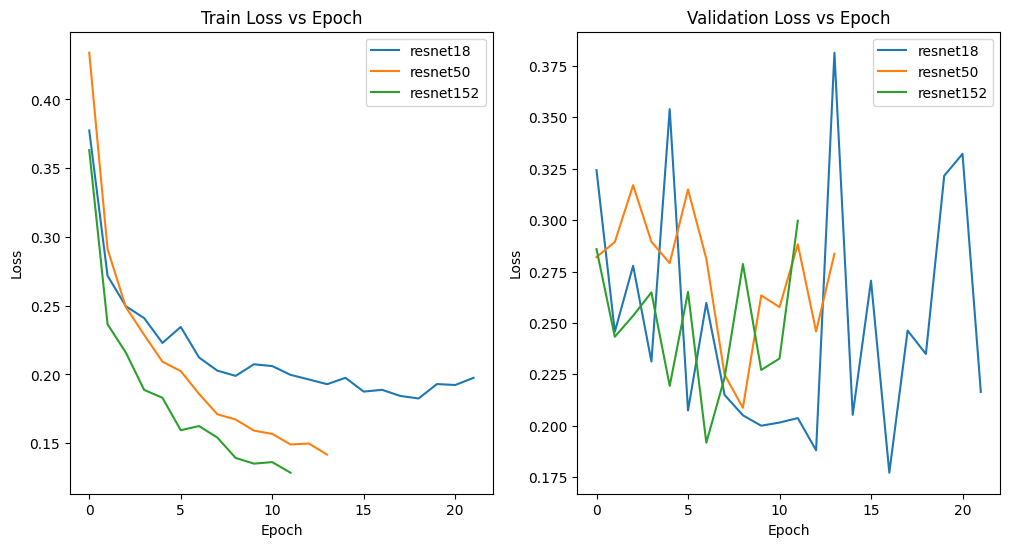

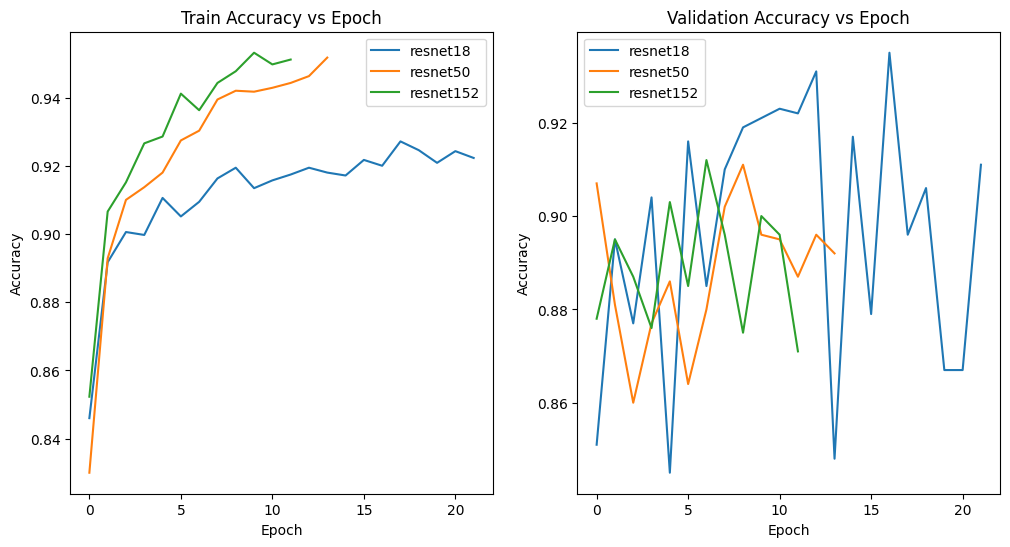

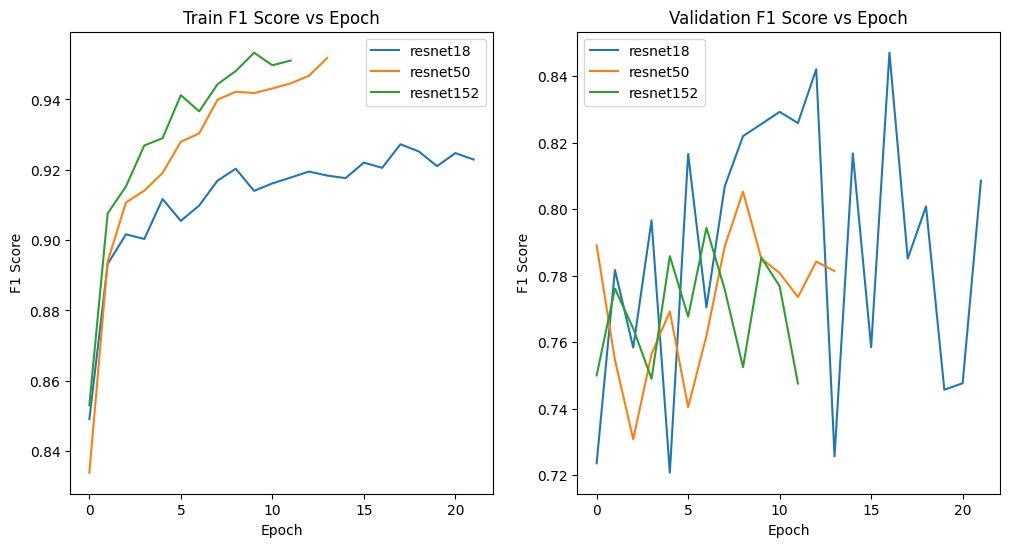

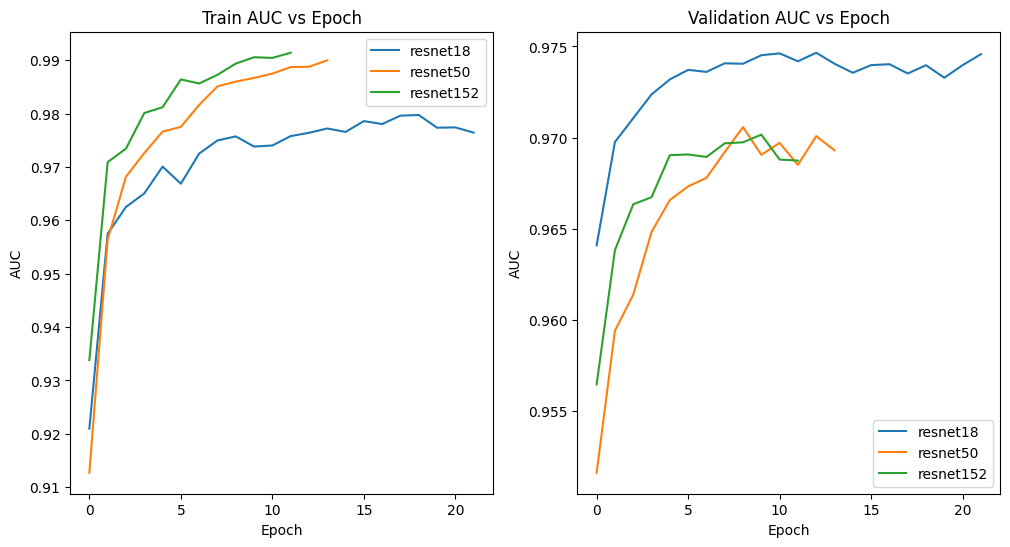

In [44]:
learning_comparasion_plot(trained_results)

Visualize the best evaluation metrics obtained for each model.

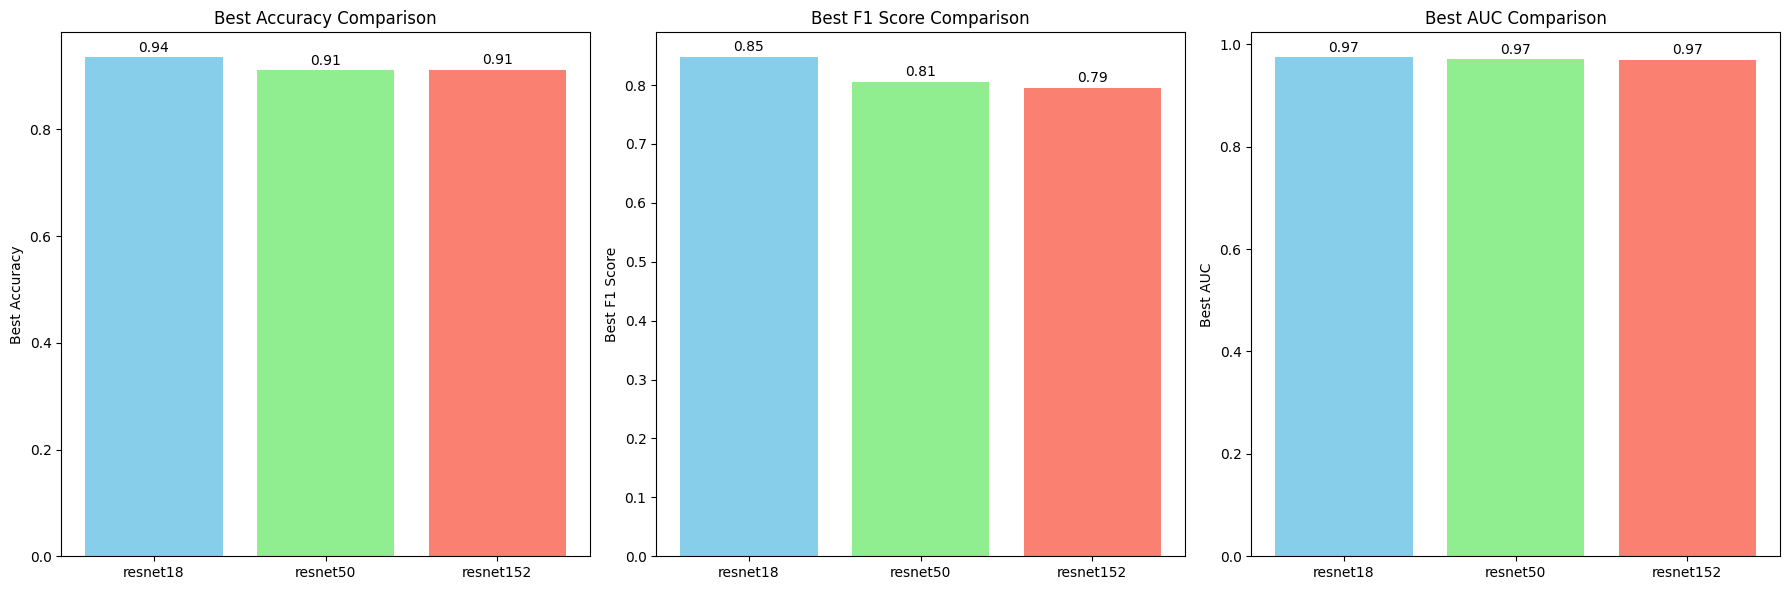

In [45]:
plot_best_matrics(trained_results)

Visualize the training time for each model.

/tmp/ipykernel_32349/2095122624.py:7: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



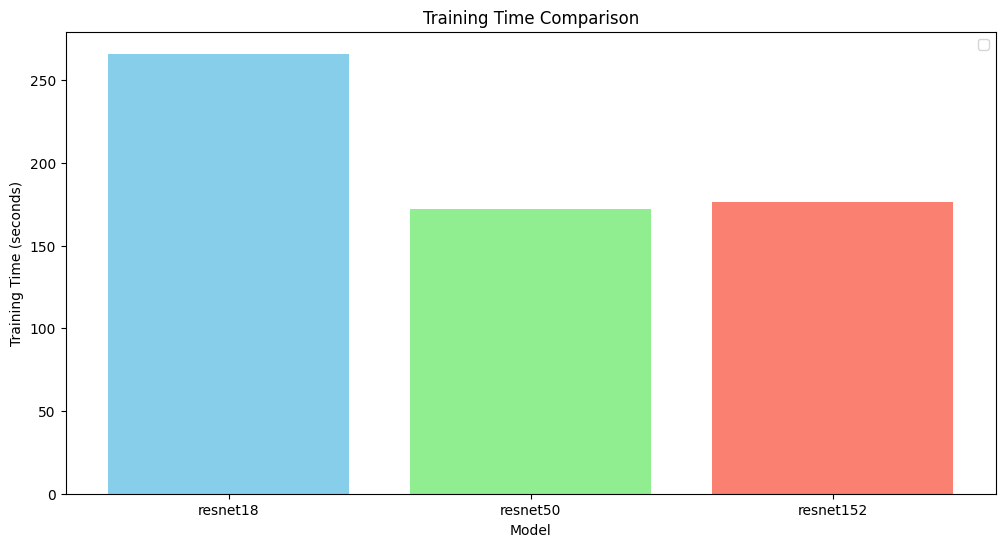

In [46]:
plot_training_time(training_times)

Evaluate the final model performance using the test dataset.

In [47]:
final_models = {}

for model_name in trained_results.keys():

  model_factory = models[model_name][0]

  weight = models[model_name][1]

  model_instance = model_factory().to(device)

  model_instance.load_state_dict(
      torch.load(f"{model_name}.pth", map_location=device)
  )


  final_models[model_name] = {
      'instance' : model_instance,
      'weight' : weight
  }

In [48]:
test_result = {}
for model_name, model_info in final_models.items():
  model_instance = model_info['instance']
  weight = model_info['weight']

  test_loader.dataset.transform = weight.transforms()

  test_result[model_name] = test_step(model_instance , test_loader,criterion, accuracy, f1_score, binary_auc)

In [49]:
import seaborn as sns

def plot_confusion_matrix(test_results):
    plt.figure(figsize=(15, 5))  #

    for i, model_name in enumerate(test_results.keys()):
        plt.subplot(1, 3, i + 1)
        sns.heatmap(test_results[model_name][4], annot=True, fmt='d', cmap='Blues')
        plt.title(f"Confusion Matrix\n{model_name}")
        plt.xlabel("Predicted Labels")
        plt.ylabel("True Labels")

    plt.tight_layout()
    plt.show()

In [50]:
import matplotlib.pyplot as plt

def plot_test_matrics(results):
  metrics = [0, 2, 3]
  metric_display_names = [ 'Accuracy', 'F1 Score', 'AUC']

  plt.figure(figsize=(20,6))
  model_names = list(results.keys())

  for i, metric in enumerate(metrics):
    best_metric_values = []
    for model_name in model_names:
      best_metric_values.append(results[model_name][metric])

    plt.subplot(1,5,i+1)
    plt.bar(model_names, best_metric_values, color =['skyblue', 'lightgreen', 'salmon'])

    plt.ylabel(f"Test {metric_display_names[i]}")
    plt.title(f"Test {metric_display_names[i]} Comparison")

    for j, v in enumerate(best_metric_values):
      plt.text(j, v + 0.01, f"{v:.2f}", ha='center')

  recalls = []
  precisions = []
  for model, values in results.items():
    cm = values[4]

    tn, fp = cm[0]
    fn, tp = cm[1]

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    precisions.append(precision)
    recalls.append(recall)

  plt.subplot(1,5,len(metrics) + 1)
  plt.bar(model_names, precisions, color =['skyblue', 'lightgreen', 'salmon'])
  plt.ylabel(f"Precision")
  plt.title(f"Precision Comparison")
  for j, v in enumerate(precisions):
      plt.text(j, v + 0.01, f"{v:.2f}", ha='center')

  plt.subplot(1,5,len(metrics) + 2)
  plt.bar(model_names, recalls, color =['skyblue', 'lightgreen', 'salmon'])
  plt.ylabel(f"Recall")
  plt.title(f"Recall Comparison")
  for j, v in enumerate(recalls):
      plt.text(j, v + 0.01, f"{v:.2f}", ha='center')

  plt.tight_layout()
  plt.show()

In [51]:
test_result

{'resnet18': (0.9279999732971191,
  0.18118592700921,
  0.804347813129425,
  0.9663556814193726,
  array([[390,  16],
         [ 20,  74]])),
 'resnet50': (0.9179999828338623,
  0.21979107707738876,
  0.7980295419692993,
  0.9621894955635071,
  array([[378,  28],
         [ 13,  81]])),
 'resnet152': (0.921999990940094,
  0.17422315338626504,
  0.800000011920929,
  0.9693689942359924,
  array([[383,  23],
         [ 16,  78]]))}

# Confusion Matrix Visualization

The confusion matrix is plotted to evaluate the performance of the classification model.  
It provides a detailed summary of prediction results by comparing the actual labels with the predicted labels.

Each cell in the matrix represents the number of predictions made by the model for a specific class:
- **True Positive (TP):** Correctly predicted positive samples.
- **True Negative (TN):** Correctly predicted negative samples.
- **False Positive (FP):** Incorrectly predicted positive samples (Type I error).
- **False Negative (FN):** Incorrectly predicted negative samples (Type II error).

By visualizing the confusion matrix, we can easily identify how well the model performs for each class and detect potential misclassification patterns. This visualization helps in understanding model strengths and weaknesses and supports further model improvement.

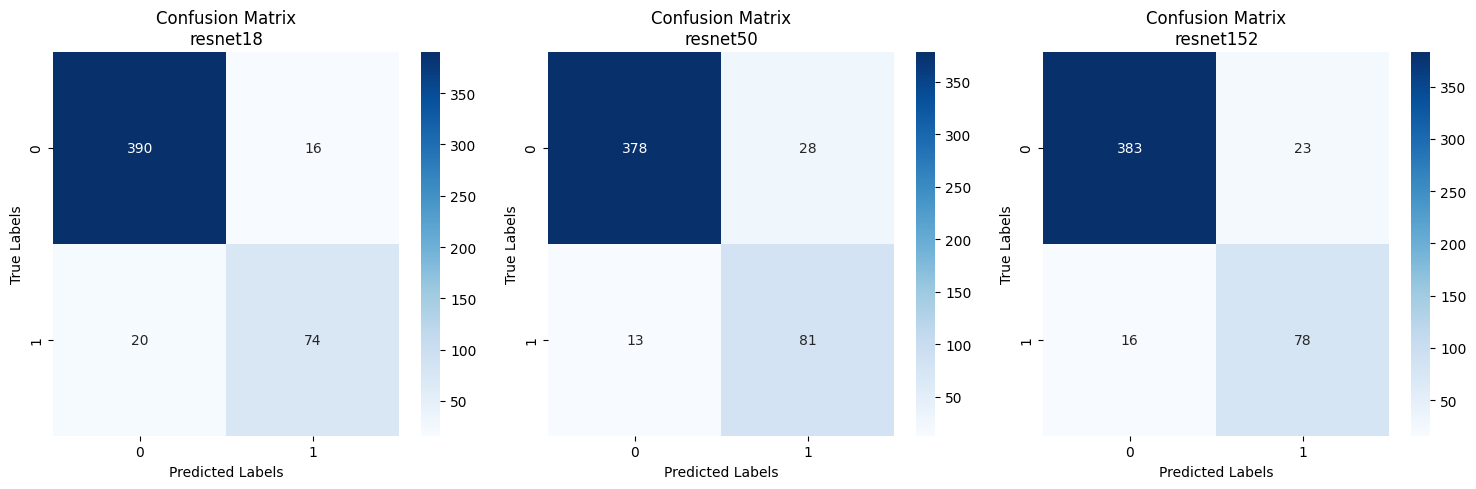

In [52]:
plot_confusion_matrix(test_result)

Plot the evaluation metrics from the test dataset to compare the performance of each trained model.

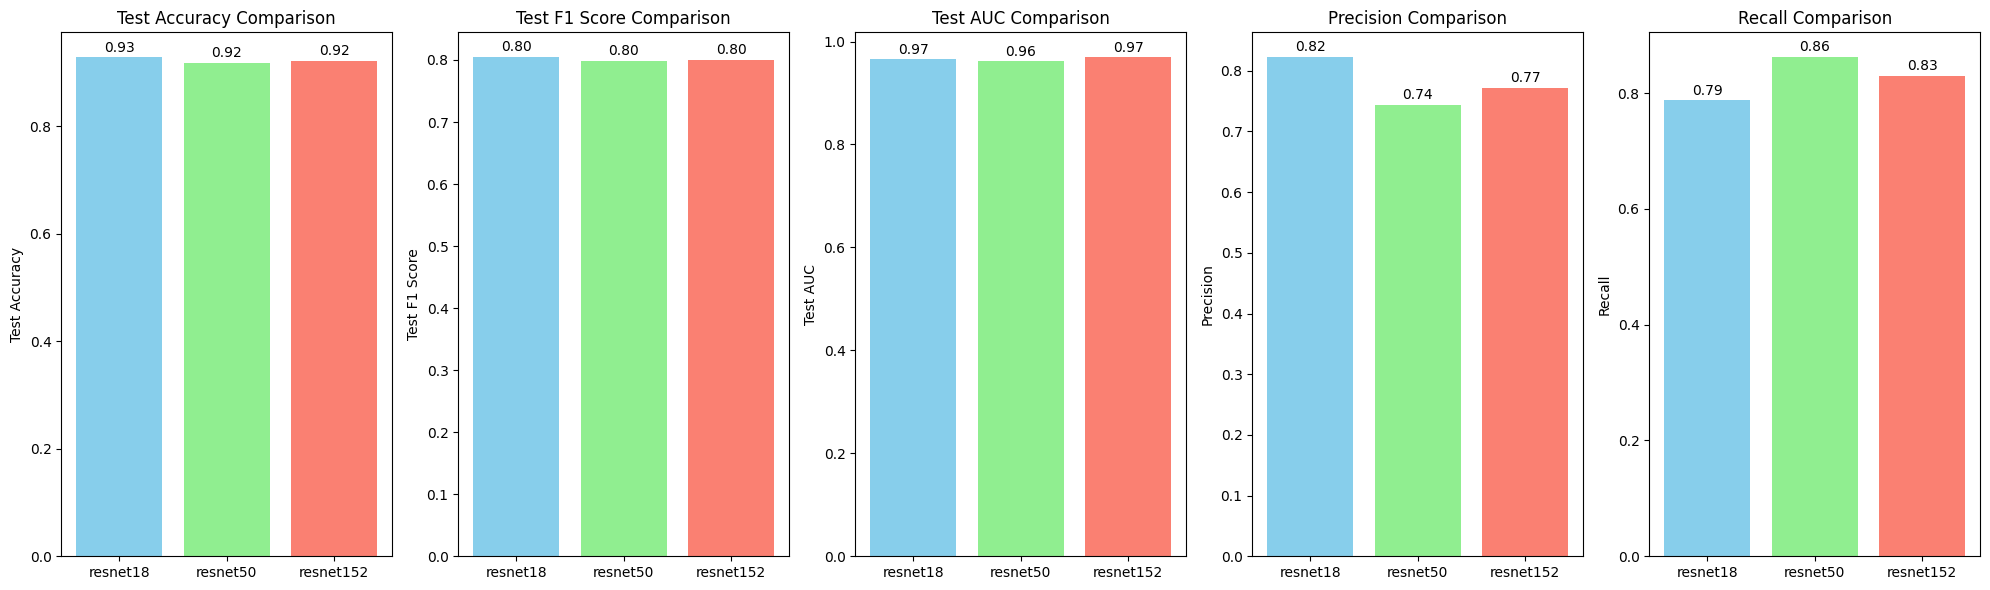

In [53]:
plot_test_matrics(test_result)

In [54]:
import random
import matplotlib.pyplot as plt
import torch
np.random.seed(42)
torch.cuda.manual_seed(42)
def plot_predictions(final_models, test_loader, num_samples=5):

  dataset = test_loader.dataset
  random_indices = random.sample(range(len(dataset)), num_samples)

  num_models = len(final_models)

  fig, axes = plt.subplots(num_models, num_samples, figsize=(num_samples*2, num_models*2))

  for row, (model_name, model_info) in enumerate(final_models.items()):

    model = model_info['instance']
    weight = model_info['weight']

    model.eval()
    dataset.transform = weight.transforms()

    for col, idx in enumerate(random_indices):

      image_tensor, label_true = dataset[idx]
      image_tensor = image_tensor.unsqueeze(0).to(device)

      with torch.inference_mode():
        output = model(image_tensor).squeeze(1)
        prob = torch.sigmoid(output).item()

      label_pred = 1 if prob >= 0.5 else 0

      image = image_tensor.squeeze().permute(1,2,0).cpu().numpy()

      ax = axes[row, col] if num_models > 1 else axes[col]

      ax.imshow(image)
      ax.axis("off")

      pred_text = "Male" if label_pred == 1 else "Female"
      true_text = "Male" if label_true == 1 else "Female"

      ax.set_title(
        f"P:{pred_text}\nT:{true_text}\n{prob:.2f}\n{model_name}",
        fontsize=8,
        color="green" if label_pred == label_true else "red"
      )

      if col == 0:
        ax.set_ylabel(model_name, fontsize=12)

  plt.tight_layout()
  plt.show()

Visualize the predictions generated by the trained model.

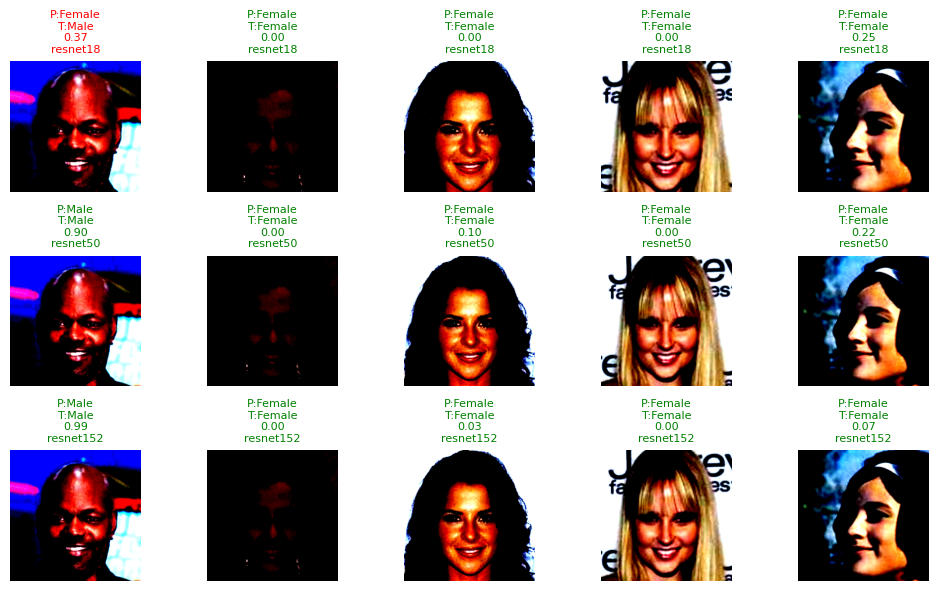

In [55]:
plot_predictions(final_models , test_loader)

Download the random sample data to test the model

In [56]:
!gdown "https://drive.google.com/uc?id=1oqjqMbPdHUp9LsehY3yoVbl-7H-38Uy5" -O sample.jpg


Downloading...
From: https://drive.google.com/uc?id=1oqjqMbPdHUp9LsehY3yoVbl-7H-38Uy5
To: /content/sample.jpg
100% 18.8k/18.8k [00:00<00:00, 59.0MB/s]


Test the trained model on random samples to observe its prediction performance.

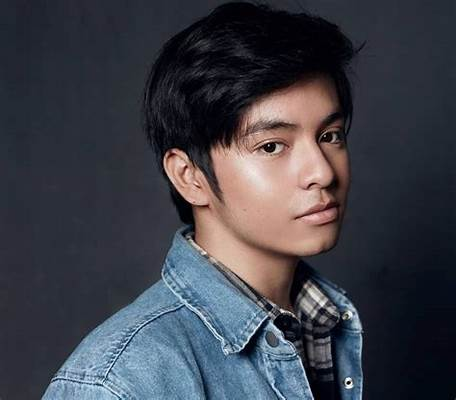

In [57]:
image = Image.open("sample.jpg")
image

Plot the prediction result for each models with random image

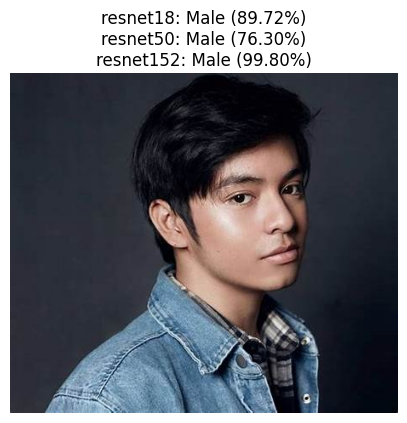

In [58]:
predictions = []

for model_name, model_info in final_models.items():

  model_instance = model_info['instance']
  weight = model_info['weight']

  model_instance.eval()
  transform = weight.transforms()

  image_tensor = transform(image).unsqueeze(0).to(device)

  with torch.inference_mode():
    output = model_instance(image_tensor).squeeze(1)
    prob = torch.sigmoid(output).item()

  label = 1 if prob >= 0.5 else 0
  label_text = "Male" if label == 1 else "Female"

  predictions.append(f"{model_name}: {label_text} ({prob:.2%})")


plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")

plt.title("\n".join(predictions), fontsize=12)

plt.show()

<h1>6. Version Control</h1>

<ul>
  <li>Mount the notebook to Google Drive.</li>
  <li>Commit the notebook changes.</li>
  <li>Push the project to the GitHub repository.</li>
</ul>

Mount the notebook to Google Drive to ensure that the notebook file is accessible and can be saved properly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!find /content/drive -name "*.ipynb" 2>/dev/null

Mounted at /content/drive


Navigate to the Google Drive folder and verify the notebook file.

In [ ]:
import os
os.chdir('/content/drive/MyDrive')

In [ ]:
os.chdir('gender_classifier_using_resnet')


Configure Git user identity

In [ ]:
!git config --global user.email "beelzebul568@gmail.com"
!git config --global user.name "FelimProject"

Copy the notebook to github repo folder

In [ ]:
import shutil

shutil.copy('/content/drive/MyDrive/Colab Notebooks/computer_vision_gender_classification.ipynb',
            '/content/drive/MyDrive/gender_classifier_using_resnet/')

!ls

Add github origin

In [ ]:
!git remote set-url origin https://github.com/FelimProject/gender_classifier_using_resnet.git


Remove the previous token to avoid conflict when push to repo

In [ ]:
import json, os

os.chdir('/content/drive/MyDrive/gender_classifier_using_resnet')

with open('computer_vision_gender_classification.ipynb', 'r') as f:
    content = f.read()

if 'ghp_' in content or 'github_pat_' in content:
    print("⚠️ Token founded in notebook! Cleaning...")

    import re
    content = re.sub(r'https://[a-zA-Z0-9_]+@github\.com', 'https://github.com', content)
    content = re.sub(r'ghp_[a-zA-Z0-9]+', 'TOKEN_REMOVED', content)
    content = re.sub(r'github_pat_[a-zA-Z0-9_]+', 'TOKEN_REMOVED', content)

    with open('computer_vision_gender_classification.ipynb', 'w') as f:
        f.write(content)
    print("✅ Token successfully cleaned!")
else:
    print("✅ No token founded")

Change the notebook version format to version 5 , to avoid conflict with gihub version format

In [ ]:
import json, os

os.chdir('/content/drive/MyDrive/gender_classifier_using_resnet')

with open('computer_vision_gender_classification.ipynb', 'r') as f:
    nb = json.load(f)

if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']
    print("✅ Metadata widgets deleted")

with open('computer_vision_gender_classification.ipynb', 'w') as f:
    json.dump(nb, f, indent=1)

print("✅ Notebook successfully changed!")

Commit and push the notebook to github repository

In [ ]:
!git add computer_vision_gender_classification.ipynb
!git commit --amend -m "Initial commit - add gender classification notebook"
!git push origin main --force